In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

In [63]:
FOLDER    = "mechanical test/"
N_CYCLES  = 5
STRAIN    = 0.5
MA_WINDOW = 50

sensors = {
    "50k test 1": {"file": "50kohm_1_test_adc_data_20260612_123857.csv", "R0": 50e3 },
    "50k test 2": {"file": "50kohm_2_test_adc_data_20260612_124824.csv", "R0": 50e3 },
    "50k test 3": {"file": "50kohm_3_test_adc_data_20260612_125644.csv", "R0": 50e3 },
    "150k":       {"file": "150kohm-mechanical.csv",                      "R0": 150e3},
    "200k":       {"file": "200kohm_test_adc_data_20260612_130535.csv",   "R0": 200e3},
    "210k":       {"file": "210kohm-mechanical.csv",                      "R0": 210e3},
    "250k":       {"file": "250kohm_test_adc_data_20260612_123025.csv",   "R0": 250e3},
    "460k":       {"file": "460kohm-mechanical.csv",                      "R0": 460e3},
}

CUTOFF_S        = {"460k": 170}
N_CYCLES_SENSOR = {"460k": 4}

dfs = {}
for label, meta in sensors.items():
    df = pd.read_csv(FOLDER + meta["file"], parse_dates=["Timestamp"])
    df["Channel_1"] = (
        df["Channel_1"]
        .replace(-1.0, np.nan)
        .interpolate(method="linear")
        .bfill()
    )
    df["elapsed_s"] = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds()
    if label in CUTOFF_S:
        cutoff   = CUTOFF_S[label]
        n_before = len(df)
        df       = df[df["elapsed_s"] <= cutoff].reset_index(drop=True)
        print(f"{label}: cut at {cutoff}s -> {len(df)}/{n_before} samples")
    df["Channel_1_ma"] = df["Channel_1"].rolling(window=MA_WINDOW, center=True, min_periods=1).mean()
    dfs[label] = df
    print(f"{label}: {len(df)} samples, {df['elapsed_s'].iloc[-1]:.1f}s")

50k test 1: 5593 samples, 280.0s
50k test 2: 4209 samples, 210.9s
50k test 3: 4202 samples, 210.8s
150k: 12683 samples, 177.6s
200k: 5125 samples, 256.8s
210k: 18215 samples, 255.0s
250k: 3604 samples, 180.5s
460k: cut at 170s -> 12139/16750 samples
460k: 12139 samples, 170.0s


## Cycle detection

In [64]:
def find_cycle_peaks(arr, n_cycles=5):
    sig_range = arr.max() - arr.min()
    min_dist  = max(1, int(0.6 * len(arr) / n_cycles))
    for frac in [0.25, 0.15, 0.05, 0.0]:
        peaks, props = find_peaks(arr, prominence=sig_range * frac, distance=min_dist)
        if len(peaks) >= n_cycles:
            break
    if len(peaks) > n_cycles:
        prom  = props.get("prominences", arr[peaks])
        peaks = np.sort(peaks[np.argsort(prom)[-n_cycles:]])
    return peaks


all_results = {}

for label, meta in sensors.items():
    df      = dfs[label]
    sig_ma  = df["Channel_1_ma"].to_numpy(dtype=float)
    t       = df["elapsed_s"].to_numpy()
    p99     = np.percentile(sig_ma, 99)
    clipped = np.clip(sig_ma, 0, p99)
    n_cyc   = N_CYCLES_SENSOR.get(label, N_CYCLES)
    peaks   = find_cycle_peaks(clipped, n_cyc)
    cycles  = []
    for i, pidx in enumerate(peaks):
        R_max     = clipped[pidx]
        seg_start = int(peaks[i - 1]) if i > 0 else 0
        segment   = clipped[seg_start:pidx]
        if len(segment) > 0:
            v_idx = seg_start + int(np.argmin(segment))
            R0    = clipped[v_idx]
        else:
            v_idx = seg_start
            R0    = meta["R0"]
        GF = ((R_max - R0) / R0) / STRAIN
        cycles.append({"cycle": i+1, "t_peak": t[int(pidx)], "t_valley": t[v_idx],
                       "p_idx": int(pidx), "v_idx": v_idx,
                       "R_max": R_max, "R0": R0, "GF": GF})
    all_results[label] = {"cycles": cycles, "p99": p99, "n_cyc": n_cyc}
    gf_vals = [c["GF"] for c in cycles]
    print(f"{label:12s}  cycles={n_cyc}  peaks={len(peaks)}  GF={[f'{g:.3f}' for g in gf_vals]}  mean={np.nanmean(gf_vals):.3f}")

50k test 1    cycles=5  peaks=5  GF=['1.078', '0.906', '0.809', '0.808', '0.757']  mean=0.872
50k test 2    cycles=5  peaks=5  GF=['1.449', '1.180', '1.083', '1.023', '0.954']  mean=1.138
50k test 3    cycles=5  peaks=5  GF=['1.482', '1.369', '1.284', '1.253', '1.227']  mean=1.323
150k          cycles=5  peaks=5  GF=['0.979', '0.996', '0.970', '0.950', '0.935']  mean=0.966
200k          cycles=5  peaks=5  GF=['5.955', '6.068', '5.121', '4.528', '4.247']  mean=5.184
210k          cycles=5  peaks=5  GF=['1.956', '1.510', '1.499', '1.458', '1.394']  mean=1.564
250k          cycles=5  peaks=5  GF=['2.050', '2.428', '2.219', '1.754', '1.510']  mean=1.992
460k          cycles=4  peaks=4  GF=['2.739', '2.458', '2.380', '2.246']  mean=2.456


## Cycles plot

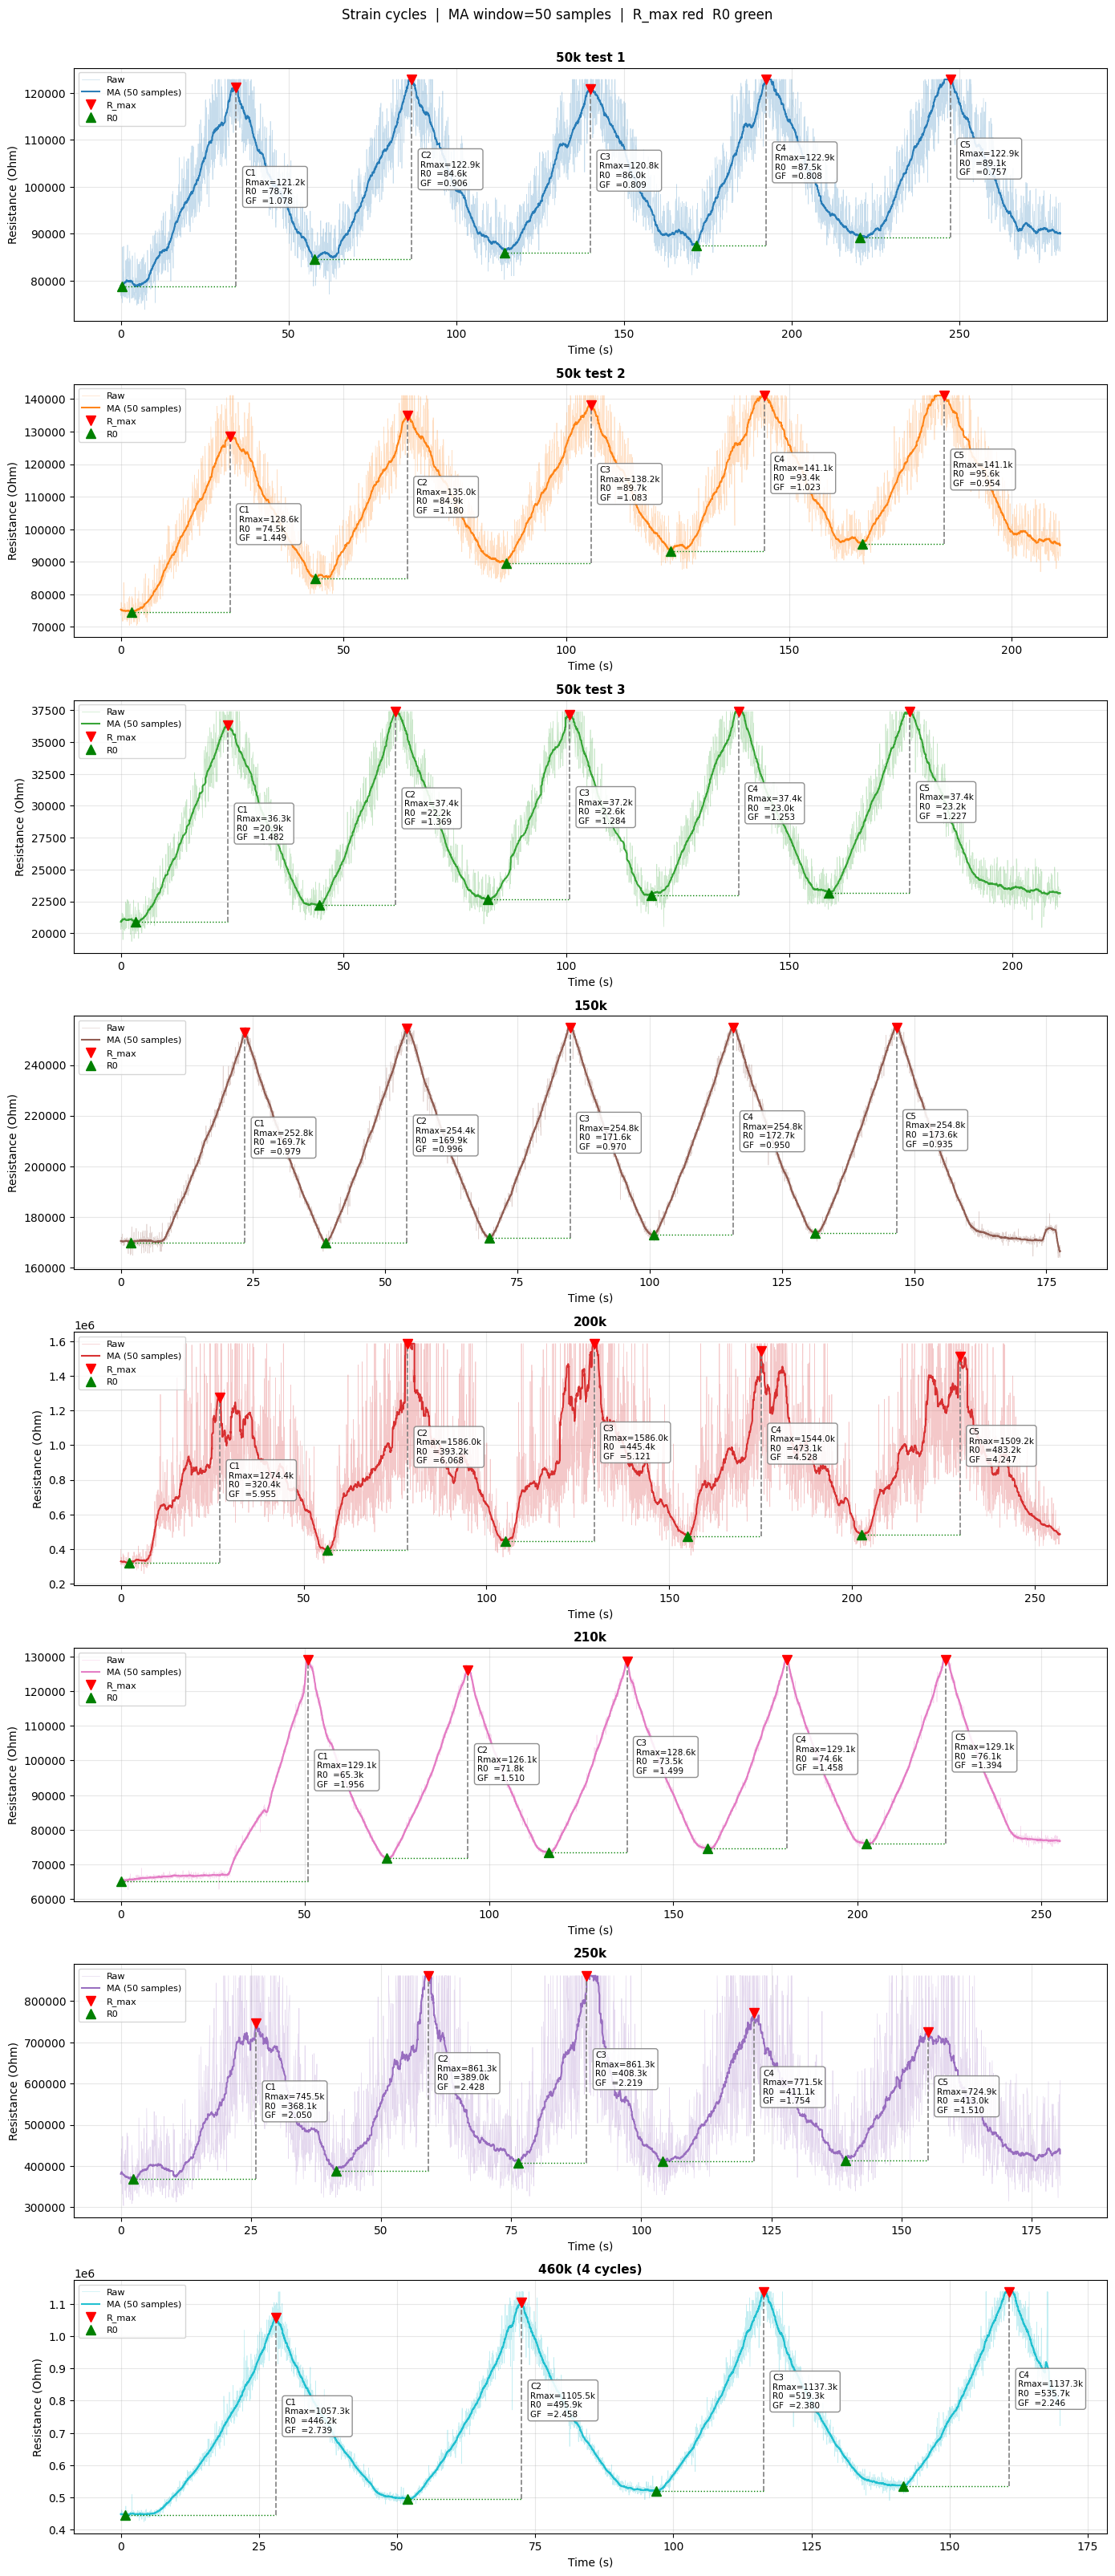

In [65]:
colors = ["#1f77b4","#ff7f0e","#2ca02c","#8c564b","#d62728","#e377c2","#9467bd","#17becf"]
fig, axes = plt.subplots(len(sensors), 1, figsize=(14, 4.0*len(sensors)), sharex=False)
for ax, (label, df), color in zip(axes, dfs.items(), colors):
    sig_raw = df["Channel_1"].to_numpy(dtype=float)
    sig_ma  = df["Channel_1_ma"].to_numpy(dtype=float)
    t       = df["elapsed_s"].to_numpy()
    p99     = all_results[label]["p99"]
    cycles  = all_results[label]["cycles"]
    n_cyc   = all_results[label]["n_cyc"]
    ax.plot(t, np.clip(sig_raw, 0, p99), color=color, lw=0.5, alpha=0.25, label="Raw")
    ax.plot(t, np.clip(sig_ma,  0, p99), color=color, lw=1.5, alpha=0.95, label=f"MA ({MA_WINDOW} samples)")
    for c in cycles:
        ax.plot(c["t_peak"],   c["R_max"], "v", color="red",   ms=9, zorder=4, label="R_max" if c["cycle"]==1 else "")
        ax.plot(c["t_valley"], c["R0"],    "^", color="green", ms=9, zorder=4, label="R0"    if c["cycle"]==1 else "")
        ax.vlines(c["t_peak"],   c["R0"], c["R_max"],  color="grey",  ls="--", lw=1.2, zorder=2)
        ax.hlines(c["R0"], c["t_valley"], c["t_peak"], color="green", ls=":",  lw=1.0, zorder=2)
        txt = f"C{c['cycle']}\nRmax={c['R_max']/1e3:.1f}k\nR0  ={c['R0']/1e3:.1f}k\nGF  ={c['GF']:.3f}"
        ax.annotate(txt, xy=(c["t_peak"], (c["R0"]+c["R_max"])/2),
                    xytext=(8,0), textcoords="offset points", fontsize=7.5, va="center",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.88))
    suffix = f" ({n_cyc} cycles)" if n_cyc != N_CYCLES else ""
    ax.set_title(label + suffix, fontsize=11, fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Resistance (Ohm)")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Strain cycles  |  MA window={MA_WINDOW} samples  |  R_max red  R0 green", fontsize=12, y=1.002)
plt.tight_layout()
plt.savefig("cycles_detected.png", dpi=150, bbox_inches="tight")
plt.show()

## GF per cycle

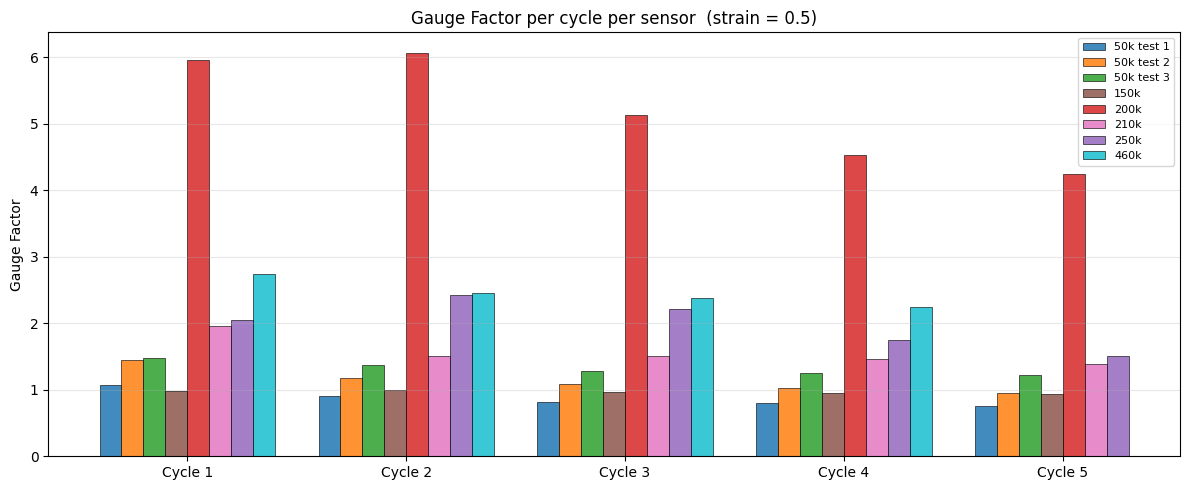

In [66]:
max_cycles = max(all_results[l]["n_cyc"] for l in sensors)
fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(1, max_cycles + 1)
n       = len(sensors)
width   = 0.8 / n
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * width
for (label, meta), color, offset in zip(sensors.items(), colors, offsets):
    gf_vals = [c["GF"] for c in all_results[label]["cycles"]]
    while len(gf_vals) < max_cycles:
        gf_vals.append(np.nan)
    ax.bar(x + offset, gf_vals, width=width, color=color, edgecolor="black", linewidth=0.5, label=label, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"Cycle {i}" for i in x])
ax.set_ylabel("Gauge Factor")
ax.set_title("Gauge Factor per cycle per sensor  (strain = 0.5)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("gf_per_cycle.png", dpi=150, bbox_inches="tight")
plt.show()

## Sensor features per cycle

| Feature | Definition |
|---|---|
| **Range** | R_max − R0 (Ω) |
| **Response time** | t_peak − t_valley (s): time from baseline to peak |
| **Resolution** | std of raw signal at the baseline window (Ω) — smallest detectable change |
| **Accuracy** | % deviation of each cycle's GF from the mean GF |
| **Hysteresis** | mean abs difference between ascending and descending curves, as % of range |
| **Cycle duration** | time between consecutive peaks (s) |
| **Drift** | relative change in R0 from cycle 1 to last cycle (%) |

In [67]:
features = {}

for label in sensors:
    cycles      = all_results[label]["cycles"]
    df          = dfs[label]
    sig_raw     = df["Channel_1"].to_numpy(dtype=float)
    sig_ma      = df["Channel_1_ma"].to_numpy(dtype=float)
    t           = df["elapsed_s"].to_numpy()
    p99         = all_results[label]["p99"]
    sig_clipped = np.clip(sig_ma, 0, p99)

    gf_vals  = [c["GF"] for c in cycles]
    gf_mean  = np.nanmean(gf_vals)
    r0_first = cycles[0]["R0"]
    r0_last  = cycles[-1]["R0"]
    drift    = (r0_last - r0_first) / r0_first * 100

    t_peaks        = [c["t_peak"] for c in cycles]
    cycle_durations = [t_peaks[i+1] - t_peaks[i] for i in range(len(t_peaks)-1)]

    per_cycle = []
    for i, c in enumerate(cycles):
        v_idx = c["v_idx"]
        p_idx = c["p_idx"]

        # Range
        delta_R = c["R_max"] - c["R0"]

        # Response time
        response_time = c["t_peak"] - c["t_valley"]

        # Resolution: noise (std) of raw signal around baseline
        win   = 40
        start = max(0, v_idx - win)
        end   = min(len(sig_raw), v_idx + win)
        resolution = float(np.std(sig_raw[start:end]))

        # Accuracy: % deviation of this cycle GF from mean GF
        accuracy = abs(c["GF"] - gf_mean) / gf_mean * 100 if gf_mean != 0 else np.nan

        # Hysteresis: ascending vs descending curve (% of range)
        asc = sig_clipped[v_idx : p_idx + 1]
        if i < len(cycles) - 1:
            nv_idx = cycles[i + 1]["v_idx"]
        else:
            nv_idx = len(sig_clipped) - 1
        desc = sig_clipped[p_idx : nv_idx + 1]

        if len(asc) > 2 and len(desc) > 2 and delta_R > 0:
            common      = np.linspace(0, 1, 100)
            asc_i       = np.interp(common, np.linspace(0, 1, len(asc)),  asc)
            desc_i      = np.interp(common, np.linspace(0, 1, len(desc)), desc[::-1])
            hysteresis  = float(np.mean(np.abs(asc_i - desc_i)) / delta_R * 100)
        else:
            hysteresis = np.nan

        per_cycle.append({
            "cycle":         i + 1,
            "GF":            c["GF"],
            "delta_R":       delta_R,
            "response_time": response_time,
            "resolution":    resolution,
            "accuracy_pct":  accuracy,
            "hysteresis_pct": hysteresis,
        })

    features[label] = {
        "per_cycle":       per_cycle,
        "cycle_durations": cycle_durations,
        "drift_pct":       drift,
        "gf_mean":         gf_mean,
    }
    print(f"{label}: drift={drift:+.1f}%  cycle_durations={[f'{d:.1f}s' for d in cycle_durations]}")

50k test 1: drift=+13.2%  cycle_durations=['52.3s', '53.3s', '52.3s', '55.0s']
50k test 2: drift=+28.2%  cycle_durations=['39.8s', '41.2s', '38.9s', '40.4s']
50k test 3: drift=+11.1%  cycle_durations=['37.6s', '39.1s', '37.9s', '38.5s']
150k: drift=+2.3%  cycle_durations=['30.7s', '30.8s', '30.9s', '30.8s']
200k: drift=+50.8%  cycle_durations=['51.3s', '51.0s', '45.7s', '54.4s']
210k: drift=+16.6%  cycle_durations=['43.4s', '43.1s', '43.4s', '43.2s']
250k: drift=+12.2%  cycle_durations=['33.2s', '30.4s', '32.2s', '33.4s']
460k: drift=+20.1%  cycle_durations=['44.5s', '43.8s', '44.5s']


### Summary table — mean ± std across cycles

In [68]:
def ms(vals, unit="", fmt=".2f"):
    """Format mean ± std."""
    v = [x for x in vals if not np.isnan(x)]
    if not v:
        return "--"
    s = f"{np.mean(v):{fmt}} ± {np.std(v):{fmt}}"
    return s + (f" {unit}" if unit else "")

rows = []
for label in sensors:
    f   = features[label]
    pc  = f["per_cycle"]
    row = {"Sensor": label}
    row["GF (mean±std)"]           = ms([p["GF"]             for p in pc], fmt=".3f")
    row["Range ΔR (kΩ)"]           = ms([p["delta_R"]/1e3    for p in pc], fmt=".1f")
    row["Response time (s)"]       = ms([p["response_time"]  for p in pc], fmt=".1f")
    row["Resolution (Ω)"]          = ms([p["resolution"]     for p in pc], fmt=".0f")
    row["Accuracy (% err vs mean)"] = ms([p["accuracy_pct"]  for p in pc], fmt=".1f")
    row["Hysteresis (%)"]          = ms([p["hysteresis_pct"] for p in pc], fmt=".1f")
    row["Cycle duration (s)"]      = ms(f["cycle_durations"],              fmt=".1f")
    row["Drift (%)"]               = f"{f['drift_pct']:+.1f}"
    rows.append(row)

df_feat = pd.DataFrame(rows).set_index("Sensor")
df_feat

,GF (mean±std),Range ΔR (kΩ),Response time (s),Resolution (Ω),Accuracy (% err vs mean),Hysteresis (%),Cycle duration (s),Drift (%)
Sensor,,,,,,,,
50k test 1,0.872 ± 0.114,36.9 ± 3.2,27.4 ± 4.3,3213 ± 215,11.1 ± 7.0,8.9 ± 3.5,53.2 ± 1.1,+13.2
50k test 2,1.138 ± 0.172,49.2 ± 2.8,20.3 ± 1.4,3682 ± 526,12.4 ± 8.7,10.1 ± 6.2,40.1 ± 0.8,+28.2
50k test 3,1.323 ± 0.093,14.8 ± 0.5,18.8 ± 1.2,777 ± 64,6.2 ± 3.3,6.4 ± 7.6,38.3 ± 0.5,+11.1
150k,0.966 ± 0.021,82.8 ± 1.1,16.5 ± 2.5,988 ± 278,1.9 ± 1.1,8.1 ± 9.3,30.8 ± 0.1,+2.3
200k,5.184 ± 0.733,1076.9 ± 83.9,23.6 ± 2.4,45656 ± 15006,12.8 ± 6.1,11.8 ± 4.9,50.6 ± 3.1,+50.8
210k,1.564 ± 0.200,56.1 ± 3.9,27.4 ± 11.7,348 ± 59,10.0 ± 8.0,9.5 ± 10.0,43.3 ± 0.1,+16.6
250k,1.992 ± 0.327,395.0 ± 59.6,17.6 ± 3.5,53929 ± 5486,14.5 ± 7.7,10.0 ± 4.0,32.3 ± 1.2,+12.2
460k,2.456 ± 0.180,610.0 ± 5.9,21.6 ± 3.3,6334 ± 1109,5.8 ± 4.5,12.1 ± 8.4,44.2 ± 0.3,+20.1


### Per-cycle detail table

In [69]:
detail_rows = []
for label in sensors:
    for p in features[label]["per_cycle"]:
        detail_rows.append({
            "Sensor":          label,
            "Cycle":           p["cycle"],
            "GF":              f"{p['GF']:.3f}",
            "ΔR (kΩ)":        f"{p['delta_R']/1e3:.1f}",
            "Response (s)":    f"{p['response_time']:.1f}",
            "Resolution (Ω)": f"{p['resolution']:.0f}",
            "Accuracy (%err)": f"{p['accuracy_pct']:.1f}",
            "Hysteresis (%)": f"{p['hysteresis_pct']:.1f}" if not np.isnan(p['hysteresis_pct']) else "--",
        })

pd.DataFrame(detail_rows).set_index(["Sensor", "Cycle"])

GF ΔR (kΩ) Response (s) Resolution (Ω) Accuracy (%err)  \
Sensor     Cycle                                                              
50k test 1 1      1.078    42.5         34.2           3089            23.7   
           2      0.906    38.3         29.1           2879             3.9   
           3      0.809    34.8         25.7           3219             7.2   
           4      0.808    35.4         20.9           3402             7.3   
           5      0.757    33.7         27.0           3475            13.1   
50k test 2 1      1.449    54.0         22.1           2816            27.4   
           2      1.180    50.1         20.6           3781             3.7   
           3      1.083    48.5         19.0           4471             4.8   
           4      1.023    47.8         21.1           3694            10.1   
           5      0.954    45.6         18.4           3651            16.2   
50k test 3 1      1.482    15.5         20.7            747            12.0   
           2      1.369    15.2         17.1            742             3.5   
           3      1.284    14.5         18.4            832             3.0   
           4      1.253    14.4         19.6            695             5.3   
           5      1.227    14.2         18.2            870             7.2   
150k       1      0.979    83.1         21.5           1508             1.3   
           2      0.996    84.6         15.4            980             3.1   
           3      0.970    83.2         15.2            678             0.4   
           4      0.950    82.1         15.1            904             1.6   
           5      0.935    81.2         15.4            870             3.2   
200k       1      5.955   954.0         24.8          23684            14.9   
           2      6.068  1192.8         21.9          38004            17.0   
           3      5.121  1140.6         24.2          51332             1.2   
           4      4.528  1070.9         20.0          69156            12.7   
           5      4.247  1026.0         26.9          46101            18.1   
210k       1      1.956    63.8         50.8            358            25.1   
           2      1.510    54.2         22.1            328             3.4   
           3      1.499    55.1         21.3            454             4.1   
           4      1.458    54.4         21.5            328             6.7   
           5      1.394    53.0         21.5            273            10.9   
250k       1      2.050   377.3         23.6          43098             2.9   
           2      2.428   472.3         17.8          55236            21.9   
           3      2.219   453.1         13.1          56933            11.4   
           4      1.754   360.4         17.6          56420            12.0   
           5      1.510   311.9         15.8          57959            24.2   
460k       1      2.739   611.1         27.2           5171            11.5   
           2      2.458   609.5         20.7           5763             0.1   
           3      2.380   618.0         19.4           6267             3.1   
           4      2.246   601.6         19.1           8134             8.6   

                 Hysteresis (%)  
Sensor     Cycle                 
50k test 1 1               13.9  
           2                5.7  
           3                5.7  
           4                6.8  
           5               12.1  
50k test 2 1               16.0  
           2                6.8  
           3                5.1  
           4                3.5  
           5               19.1  
50k test 3 1                2.3  
           2                3.5  
           3                2.4  
           4                2.4  
           5               21.6  
150k       1               12.4  
           2                0.7  
           3                1.1  
           4                1.7  
           5               24.5  
200k       1               18.8  